In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
print("Environment ready")


Environment ready


In [3]:
from pathlib import Path
DATA_DIR = Path("../data/raw")
files= list(DATA_DIR.glob("*"))
for file in files:
    print(file.name)

Monthly-AE-Time-Series-August-2026-YG43sd.xls


In [4]:
ae= pd.read_excel("../data/raw/Monthly-AE-Time-Series-August-2026-YG43sd.xls", sheet_name="Activity", header=13)
ae.head()

,Unnamed: 0,Period,Type 1 Departments - Major A&E,Type 2 Departments - Single Specialty,Type 3 Departments - Other A&E/Minor Injury Unit,Total Attendances,Emergency Admissions via Type 1 A&E,Emergency Admissions via Type 2 A&E,Emergency Admissions via Type 3 and 4 A&E,Total Emergency Admissions via A&E,Other Emergency Admissions (i.e not via A&E),Total Emergency Admissions,Number of patients spending >4 hours from decision to admit to admission,Number of patients spending >12 hours from decision to admit to admission,Unnamed: 14,Operational standard (Performance),Unnamed: 16,0.95
0,NaN,2010-08-01,1.138652e+06,54371.000000,559358.000000,1.752381e+06,287438.000000,5367.000000,8081.000000,300886.000000,124816.000000,425702.000000,3697.000000,1.0,NaN,0.95,NaN,NaN
1,NaN,2010-09-01,1.150728e+06,55181.000000,550359.000000,1.756268e+06,293991.000000,5543.000000,3673.000000,303207.000000,121693.000000,424900.000000,5907.000000,0.0,NaN,0.95,NaN,NaN
2,NaN,2010-10-01,1.163143e+06,54961.000000,583244.000000,1.801348e+06,303452.000000,5485.000000,2560.000000,311497.000000,124718.000000,436215.000000,6932.000000,0.0,NaN,0.95,NaN,NaN
3,NaN,2010-11-01,1.111295e+06,53727.428571,486005.428571,1.651027e+06,297832.000000,5731.142857,3279.000000,306842.142857,122256.857143,429099.000000,7179.000000,2.0,NaN,0.95,NaN,NaN
4,NaN,2010-12-01,1.159204e+06,45536.428571,533000.857143,1.737741e+06,318602.428571,6277.000000,3198.428571,328077.857143,124650.857143,452728.714286,13818.142857,15.0,NaN,0.95,NaN,NaN


In [5]:
ae.columns.tolist()

['Unnamed: 0',
 'Period',
 'Type 1 Departments - Major A&E',
 'Type 2 Departments - Single Specialty',
 'Type 3 Departments - Other A&E/Minor Injury Unit',
 'Total Attendances',
 'Emergency Admissions via Type 1 A&E',
 'Emergency Admissions via Type 2 A&E',
 'Emergency Admissions via Type 3 and 4 A&E',
 'Total Emergency Admissions via A&E',
 'Other Emergency Admissions (i.e not via A&E)',
 'Total Emergency Admissions',
 'Number of patients spending >4 hours from decision to admit to admission',
 'Number of patients spending >12 hours from decision to admit to admission',
 'Unnamed: 14',
 'Operational standard (Performance)',
 'Unnamed: 16',
 0.95]

In [6]:
ae.shape

(193, 18)

In [7]:
ae.info()

<class 'pandas.DataFrame'>
RangeIndex: 193 entries, 0 to 192
Data columns (total 18 columns):
 #   Column                                                                     Non-Null Count  Dtype         
---  ------                                                                     --------------  -----         
 0   Unnamed: 0                                                                 0 non-null      float64       
 1   Period                                                                     193 non-null    datetime64[us]
 2   Type 1 Departments - Major A&E                                             193 non-null    float64       
 3   Type 2 Departments - Single Specialty                                      193 non-null    float64       
 4   Type 3 Departments - Other A&E/Minor Injury Unit                           193 non-null    float64       
 5   Total Attendances                                                          193 non-null    float64       
 6   Emergency Adm

In [8]:
#cleaning
ae=ae.dropna(axis=1, how="all")
print("Shape after removing empty columns:", ae.shape)

Shape after removing empty columns: (193, 14)


In [9]:
ae.info()

<class 'pandas.DataFrame'>
RangeIndex: 193 entries, 0 to 192
Data columns (total 14 columns):
 #   Column                                                                     Non-Null Count  Dtype         
---  ------                                                                     --------------  -----         
 0   Period                                                                     193 non-null    datetime64[us]
 1   Type 1 Departments - Major A&E                                             193 non-null    float64       
 2   Type 2 Departments - Single Specialty                                      193 non-null    float64       
 3   Type 3 Departments - Other A&E/Minor Injury Unit                           193 non-null    float64       
 4   Total Attendances                                                          193 non-null    float64       
 5   Emergency Admissions via Type 1 A&E                                        193 non-null    float64       
 6   Emergency Adm

In [10]:
ae["Period"] = pd.to_datetime(ae["Period"])

In [11]:
print("Start:", ae["Period"].min())
print("End:", ae["Period"].max())

Start: 2010-08-01 00:00:00
End: 2026-08-01 00:00:00


In [12]:
ae.duplicated().sum()

np.int64(0)

In [13]:
missing=ae.isna().sum().sort_values(ascending=False)
missing

Operational standard (Performance)                                           106
Period                                                                         0
Type 2 Departments - Single Specialty                                          0
Type 3 Departments - Other A&E/Minor Injury Unit                               0
Total Attendances                                                              0
Type 1 Departments - Major A&E                                                 0
Emergency Admissions via Type 1 A&E                                            0
Emergency Admissions via Type 2 A&E                                            0
Total Emergency Admissions via A&E                                             0
Emergency Admissions via Type 3 and 4 A&E                                      0
Other Emergency Admissions (i.e not via A&E)                                   0
Total Emergency Admissions                                                     0
Number of patients spending 

In [14]:
expected_months=pd.date_range(start=ae["Period"].min(), end=ae["Period"].max(), freq="MS")
missing_months=expected_months.difference(ae["Period"])
print(len(expected_months))
print(len(ae))
print(len(missing_months))

if(len(missing_months)>0):
    print(missing_months)

193
193
0


In [15]:
ae[["Period", "Total Attendances"]].head(10)

,Period,Total Attendances
0,2010-08-01,1.752381e+06
1,2010-09-01,1.756268e+06
2,2010-10-01,1.801348e+06
3,2010-11-01,1.651027e+06
4,2010-12-01,1.737741e+06
5,2011-01-01,1.727797e+06
6,2011-02-01,1.599364e+06
7,2011-03-01,1.863441e+06
8,2011-04-01,1.844375e+06
9,2011-05-01,1.873695e+06


In [16]:
ae[["Period", "Total Attendances"]].tail(10)

,Period,Total Attendances
183,2025-11-01,2347046.0
184,2025-12-01,2326139.0
185,2026-01-01,2319296.0
186,2026-02-01,2117450.0
187,2026-03-01,2432272.0
188,2026-04-01,2345329.0
189,2026-05-01,2457398.0
190,2026-06-01,2437906.0
191,2026-07-01,2487580.0
192,2026-08-01,2342959.0


In [17]:
ae["Total Attendances"].describe()

count    1.930000e+02
mean     1.981408e+06
std      2.483261e+05
min      9.165750e+05
25%      1.832304e+06
50%      1.969691e+06
75%      2.165951e+06
max      2.487580e+06
Name: Total Attendances, dtype: float64

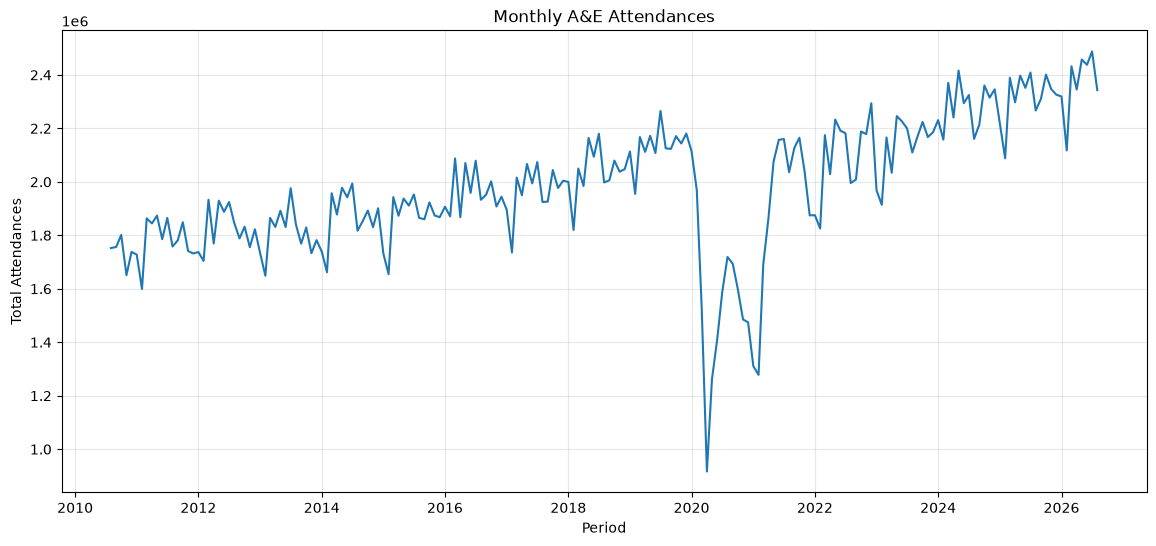

In [18]:
#graph
#EDA STARTS

plt.figure(figsize=(14, 6))
plt.plot(
    ae["Period"],
    ae["Total Attendances"],

)

plt.title("Monthly A&E Attendances")
plt.xlabel("Period")
plt.ylabel("Total Attendances")
plt.grid(alpha=0.3)

In [19]:
# Extract month information
ae["Month"] = ae["Period"].dt.month
ae["Month_Name"] = ae["Period"].dt.month_name()

monthly_seasonality = (
    ae.groupby(["Month", "Month_Name"])["Total Attendances"]
    .mean()
    .reset_index()
    .sort_values("Month")
)

monthly_seasonality

,Month,Month_Name,Total Attendances
0,1,January,1.913940e+06
1,2,February,1.812570e+06
2,3,March,2.039881e+06
3,4,April,1.927456e+06
4,5,May,2.073225e+06
5,6,June,2.036329e+06
6,7,July,2.103835e+06
7,8,August,1.970042e+06
8,9,September,1.958719e+06
9,10,October,2.022632e+06


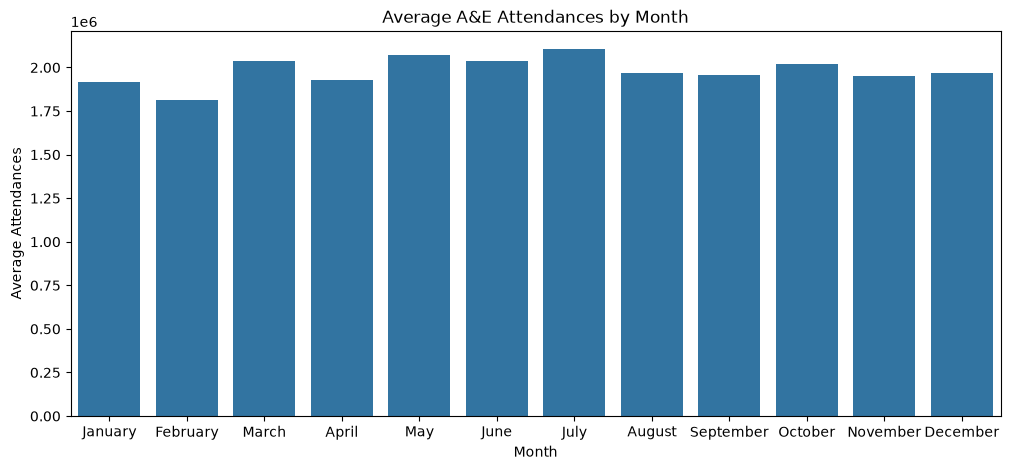

In [20]:
plt.figure(figsize=(12, 5))

sns.barplot(
    data=monthly_seasonality,
    x="Month_Name",
    y="Total Attendances"
)

plt.title("Average A&E Attendances by Month")
plt.xlabel("Month")
plt.ylabel("Average Attendances")
plt.show()

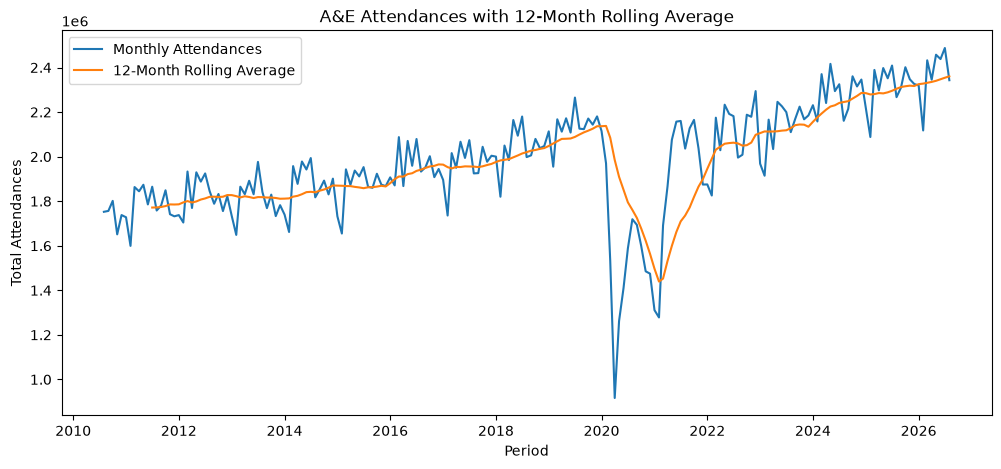

In [21]:
ae["Rolling_12M"]=(ae["Total Attendances"].rolling(window=12).mean())
plt.figure(figsize=(12, 5))
plt.plot(
    ae["Period"],
    ae["Total Attendances"],
    label="Monthly Attendances",

)
plt.plot(
    ae["Period"],
    ae["Rolling_12M"],
    label="12-Month Rolling Average",
)
plt.title("A&E Attendances with 12-Month Rolling Average")
plt.xlabel("Period")
plt.ylabel("Total Attendances")
plt.legend()
plt.show()

In [22]:
ae["Y/Y Change"] = (ae["Total Attendances"].pct_change(periods=12) * 100)
ae[["Period", "Total Attendances", "Y/Y Change"]].tail(20)

,Period,Total Attendances,Y/Y Change
173,2025-01-01,2218130.0,-0.569072
174,2025-02-01,2088071.0,-3.232472
175,2025-03-01,2389064.0,0.794989
176,2025-04-01,2297421.0,2.532861
177,2025-05-01,2397529.0,-0.776520
178,2025-06-01,2351581.0,2.507165
179,2025-07-01,2408866.0,3.614627
180,2025-08-01,2266937.0,4.912368
181,2025-09-01,2310222.0,4.335844
182,2025-10-01,2401266.0,1.725456


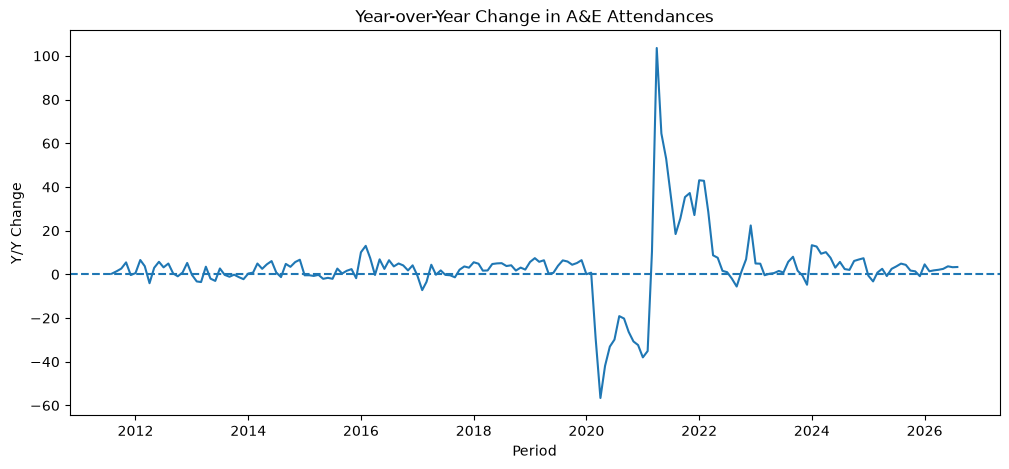

In [23]:
plt.figure(figsize=(12, 5))
plt.plot(
    ae["Period"],
    ae["Y/Y Change"],
    label="Year by year change"
)
plt.axhline(0, linestyle="--")
plt.title("Year-over-Year Change in A&E Attendances")
plt.xlabel("Period")
plt.ylabel("Y/Y Change")
plt.show()

In [24]:
 #statsmodeling
from statsmodels.tsa.seasonal import seasonal_decompose
#its use is to decompose the time series into its components: trend, seasonality, and residuals.
ts=ae.set_index("Period")["Total Attendances"]
ts.head()

Period
2010-08-01    1.752381e+06
2010-09-01    1.756268e+06
2010-10-01    1.801348e+06
2010-11-01    1.651027e+06
2010-12-01    1.737741e+06
Name: Total Attendances, dtype: float64

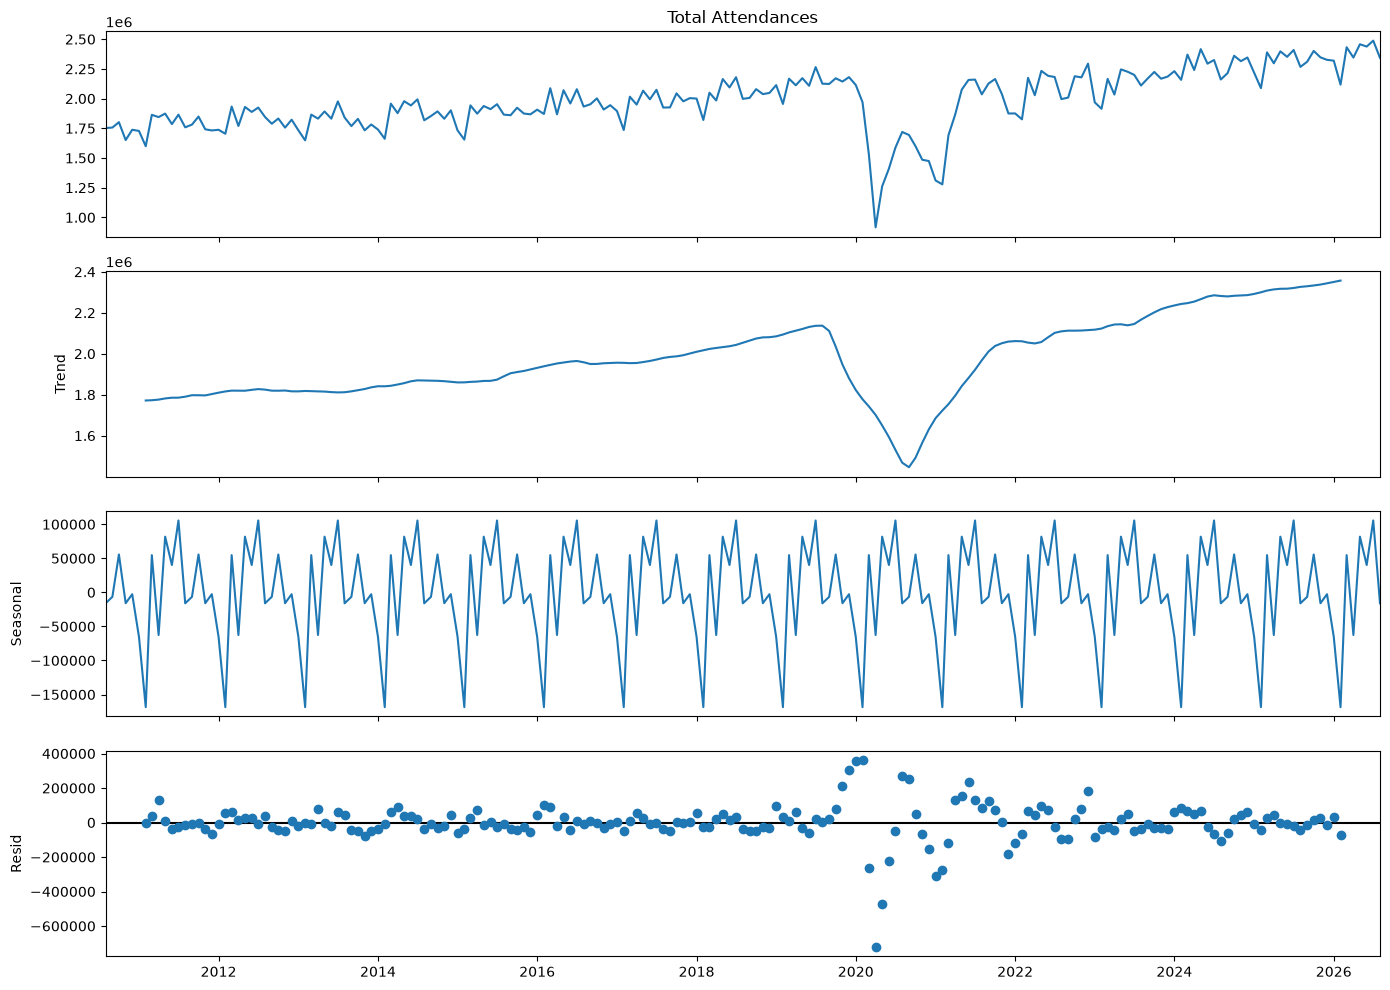

In [25]:
decomposition = seasonal_decompose(ts, model="additive", period=12)
fig=decomposition.plot()
fig.set_size_inches(14, 10)
plt.tight_layout()
plt.show()

In [26]:
from statsmodels.tsa.stattools import adfuller
#this function is used to perform the Augmented Dickey-Fuller test, which is a statistical test used to determine whether a time series is stationary or not. A stationary time series has constant mean and variance over time, which is an important assumption for many time series forecasting models. The ADF test helps in identifying if differencing or other transformations are needed to make the series stationary before applying forecasting techniques.
ts=ae.set_index("Period")["Total Attendances"]
adf_res=adfuller(ts.dropna())
adf_res[0]
adf_res[1]

if(adf_res[1]<0.05):
    print("Result: series stationary")
else:
    print("Result: series non-stationary")

Result: series non-stationary


C:\Users\Himanshi Arora\AppData\Local\Temp\ipykernel_21792\2707584115.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_res=adfuller(ts.dropna())


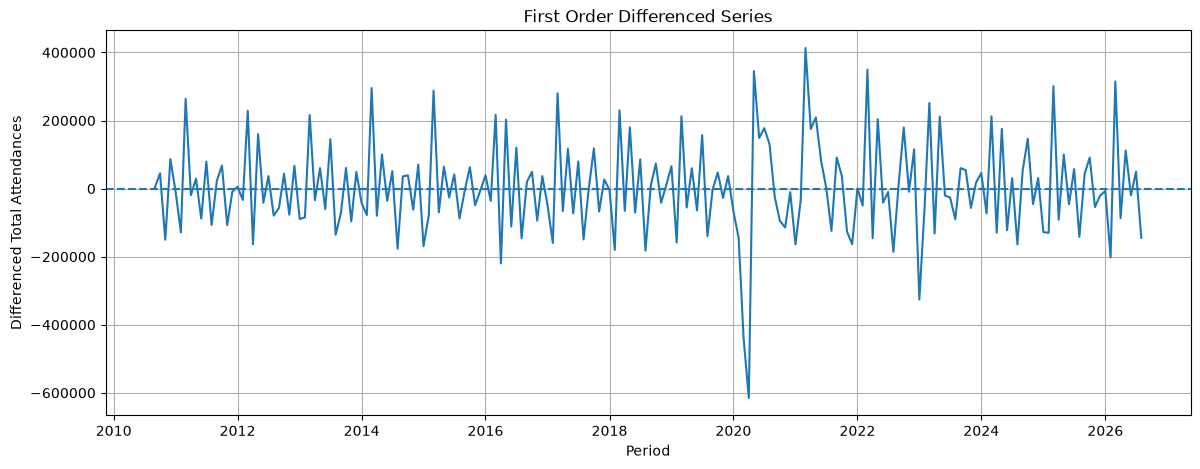

In [27]:
ts_diff=ts.diff().dropna()
plt.figure(figsize=(14, 5))
plt.plot(ts_diff)
plt.axhline(0, linestyle="--")
plt.title("First Order Differenced Series")
plt.xlabel("Period")
plt.ylabel("Differenced Total Attendances")
plt.grid()
plt.show()


In [28]:
adf_diff=adfuller(ts_diff)
adf_diff[0]
adf_diff[1]
if(adf_diff[1]<0.05):
    print("ts is stationary")
else:
    print("ts is non-stationary")

ts is stationary


C:\Users\Himanshi Arora\AppData\Local\Temp\ipykernel_21792\3884356959.py:1: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_diff=adfuller(ts_diff)


In [29]:
ts_seas_diff=ts.diff(12).dropna()
adf_seas=adfuller(ts_seas_diff)
adf_seas[0]
adf_seas[1]
if(adf_seas[1]<0.05):
    print("ts of season is stationary")
else:
    print("ts of season non-stationary")

ts of season is stationary


C:\Users\Himanshi Arora\AppData\Local\Temp\ipykernel_21792\2926356062.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_seas=adfuller(ts_seas_diff)


<Figure size 1200x500 with 0 Axes>

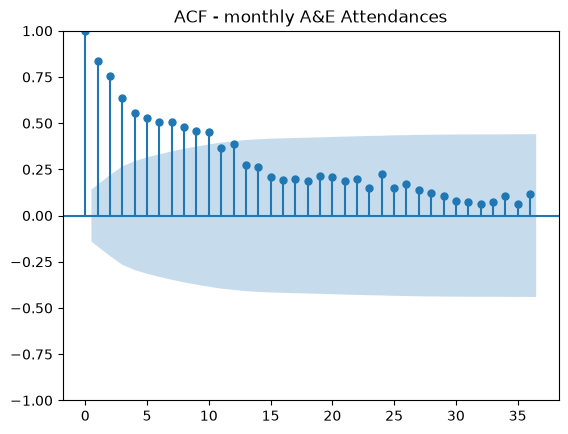

In [30]:
#ACF AND PACF
#ACF (Autocorrelation Function) and PACF (Partial Autocorrelation Function) are statistical tools used in time series analysis to understand the relationship between observations in a time series and their lagged values. ACF measures the correlation between the time series and its lagged values, while PACF measures the correlation between the time series and its lagged values after removing the effects of shorter lags. These functions help identify the order of autoregressive (AR) and moving average (MA) components in ARIMA models, aiding in model selection and forecasting.
#BASICALLY DOING ARIMA MODELING
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plt.figure(figsize=(12,5))
plot_acf(ts, lags=36)
plt.title("ACF - monthly A&E Attendances")
plt.show()

<Figure size 1200x500 with 0 Axes>

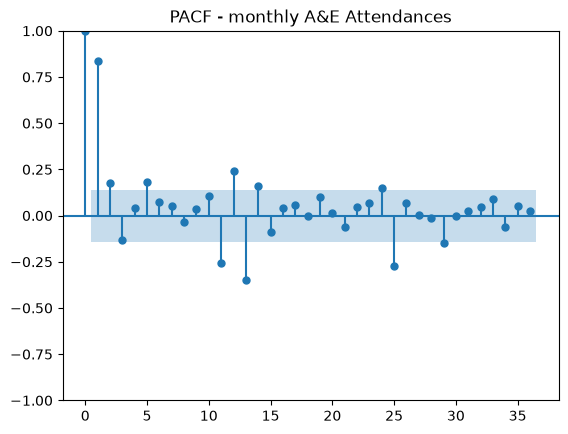

In [31]:
plt.figure(figsize=(12,5))
plot_pacf(ts, lags=36, method="ywm")
#ywm model because it is a more robust method for estimating the partial autocorrelation function, especially in the presence of non-stationary data or when the time series exhibits strong trends or seasonality. The Yule-Walker method (ywm) provides more reliable estimates of the PACF by accounting for these characteristics, making it a preferred choice in many time series analyses.
plt.title("PACF - monthly A&E Attendances")
plt.show()

In [32]:
print("ADF Results")
print("Raw series:", adf_res[1])
print("First difference:", adf_diff[1])
print("seasonal_difference:", adf_seas[1])

ADF Results
Raw series: 0.37915556816130047
First difference: 0.00021020503633601223
seasonal_difference: 0.00036350530400812957


In [33]:
diff_1=ts.diff().dropna()
diff_seas=ts.diff(12).dropna()
print("-" *50)
adf_diff1= adfuller(diff_1)
adf_diff_seas=adfuller(diff_seas)

--------------------------------------------------


C:\Users\Himanshi Arora\AppData\Local\Temp\ipykernel_21792\1019296462.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_diff1= adfuller(diff_1)
C:\Users\Himanshi Arora\AppData\Local\Temp\ipykernel_21792\1019296462.py:5: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_diff_seas=adfuller(diff_seas)


In [34]:
print(f"Ordinary difference(d=1): p-value = {adf_diff1[1]:.6f}")
print(f"Seasonal difference(d=12): p-value = {adf_diff_seas[1]:.6f}")

Ordinary difference(d=1): p-value = 0.000210
Seasonal difference(d=12): p-value = 0.000364


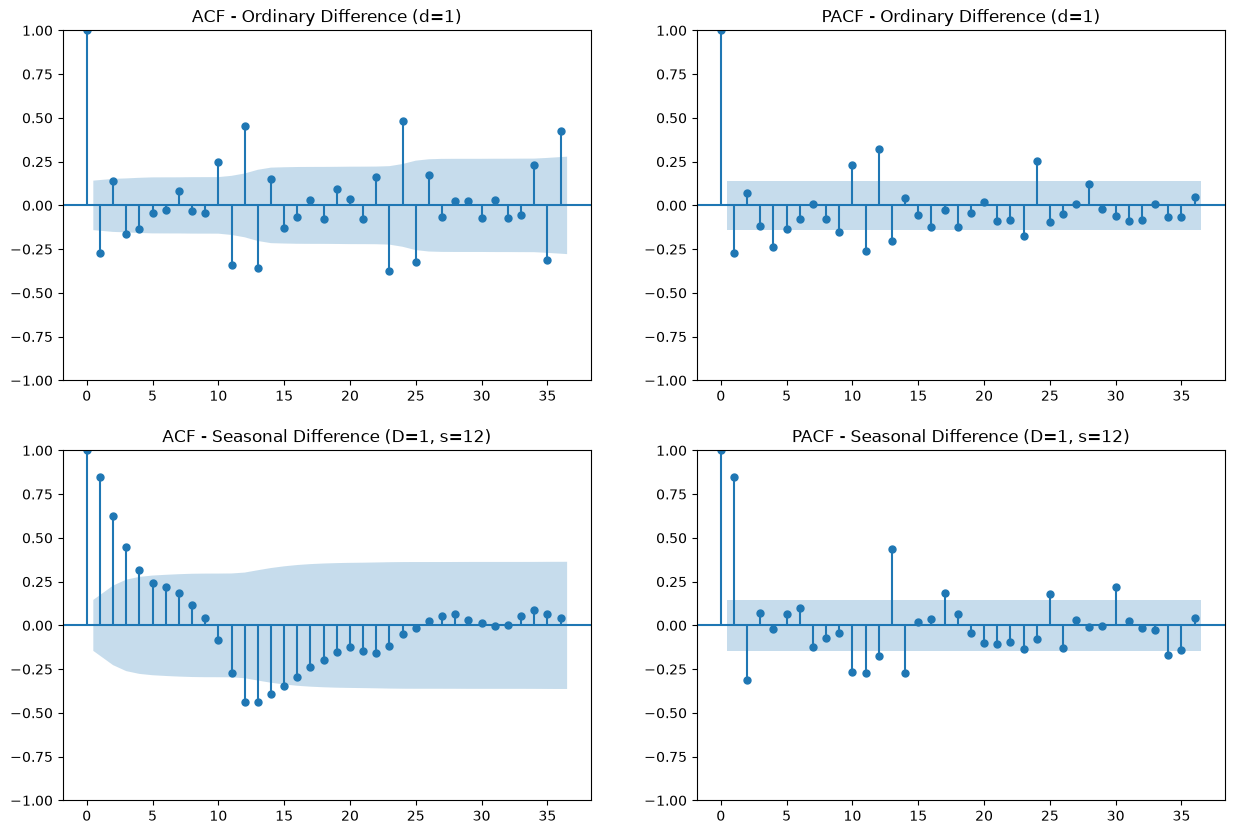

In [35]:
fig, axes= plt.subplots(2,2,figsize=(15,10))
plot_acf(diff_1, lags=36, ax=axes[0,0])
axes[0,0].set_title("ACF - Ordinary Difference (d=1)")
plot_pacf(diff_1, lags=36, method="ywm", ax=axes[0,1])
axes[0,1].set_title("PACF - Ordinary Difference (d=1)")
plot_acf(diff_seas, lags=36, ax=axes[1,0])
axes[1,0].set_title("ACF - Seasonal Difference (D=1, s=12)")
plot_pacf(diff_seas, lags=36, method="ywm", ax=axes[1,1])
axes[1,1].set_title("PACF - Seasonal Difference (D=1, s=12)")
plt.show()

In [36]:
diff_b=ts.diff().diff(12).dropna()
adf_b=adfuller(diff_b)
print(f"Both Ordinary and Seasonal difference= {adf_b[1]:.6f}")
print(f"ADF p-value= {adf_b[1]:.6f}")

Both Ordinary and Seasonal difference= 0.000019
ADF p-value= 0.000019


C:\Users\Himanshi Arora\AppData\Local\Temp\ipykernel_21792\3392466139.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_b=adfuller(diff_b)


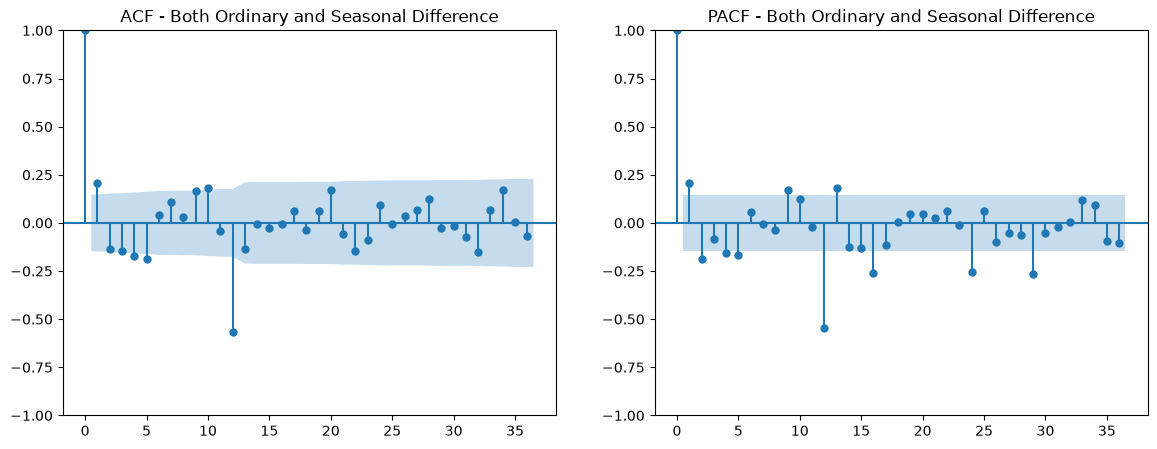

In [37]:
fig, axes=plt.subplots(1,2,figsize=(14,5))
plot_acf(diff_b, lags=36, ax=axes[0])
axes[0].set_title("ACF - Both Ordinary and Seasonal Difference")
plot_pacf(diff_b, lags=36, method="ywm", ax=axes[1])
axes[1].set_title("PACF - Both Ordinary and Seasonal Difference")
plt.show()

In [38]:
#test-train splitting yayyy
test_size=24
train=ts.iloc[:-test_size]
test=ts.iloc[-test_size:]
print(train.index.min(), "to", train.index.max())
print(test.index.min(), "to", test.index.max())
print(len(train))
print(len(test))

2010-08-01 00:00:00 to 2024-08-01 00:00:00
2024-09-01 00:00:00 to 2026-08-01 00:00:00
169
24


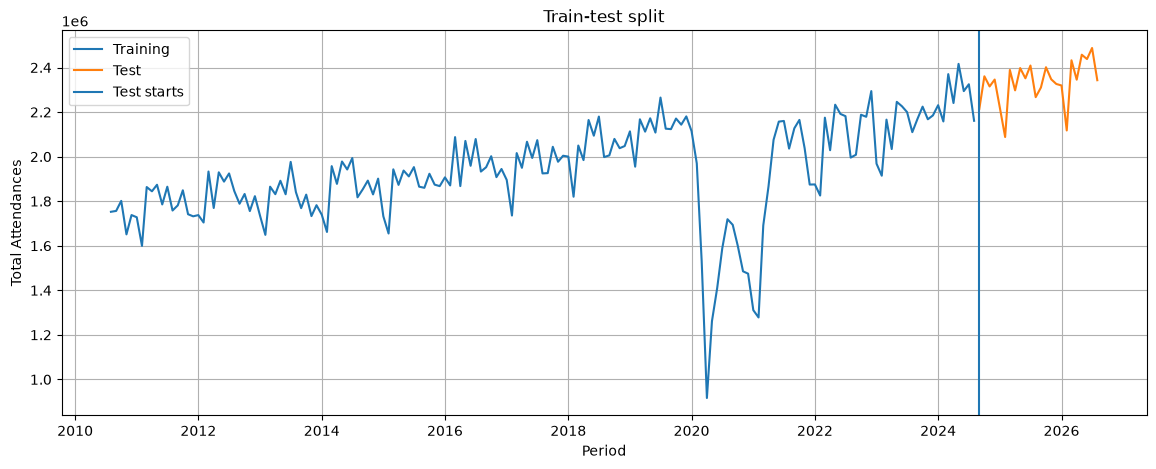

In [39]:
plt.figure(figsize=(14,5))
plt.plot(train.index, train, label="Training")
plt.plot(test.index, test, label="Test")
plt.axvline(test.index[0], label= "Test starts")
plt.title("Train-test split")
plt.xlabel("Period")
plt.ylabel("Total Attendances")
plt.legend()
plt.grid()
plt.show()

In [42]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
can_mod={
    "SARIMA(1,0,0)(1,1,0,12)": ((1,0,0), (1,1,0,12)),
    "SARIMA(1,0,0)(0,1,1,12)": ((1,0,0), (0,1,1,12)),
    "SARIMA(1,0,1)(1,1,0,12)" : ((1,0,1), (1,1,0,12)),
    "SARIMA(1,0,1)(0,1,1,12)": ((1,0,1), (0,1,1,12)),
    "SARIMA(2,0,0)(1,1,0,12)": ((2,0,0), (1,1,0,12)),
    "SARIMA(1,0,0)(1,1,1,12)":((1,0,0), (1,1,1,12))
}
fit_mod={}
for name, (order, seasonal_order) in can_mod.items():
    print(f"Fitting {name}")
    model= SARIMAX(
        train, order=order, seasonal_order=seasonal_order, enforce_stationarity=False, enforce_invertibility=False
    )
    fitted=model.fit(disp=False)
    fit_mod[name]=fitted
    print(f"AIC: {fitted.aic:.2f}")
    print(f"BIC: {fitted.bic:.2f}")
    print()

Fitting SARIMA(1,0,0)(1,1,0,12)
AIC: 3798.44
BIC: 3807.35

Fitting SARIMA(1,0,0)(0,1,1,12)
AIC: 3804.84
BIC: 3813.75

Fitting SARIMA(1,0,1)(1,1,0,12)


c:\Users\Himanshi Arora\OneDrive\Desktop\self-projects\hospital resource intelligence\Hospital-Resource-Intelligence-Decision-Support-System\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Himanshi Arora\OneDrive\Desktop\self-projects\hospital resource intelligence\Hospital-Resource-Intelligence-Decision-Support-System\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Himanshi Arora\OneDrive\Desktop\self-projects\hospital resource intelligence\Hospital-Resource-Intelligence-Decision-Support-System\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Himansh

AIC: 3784.75
BIC: 3796.63

Fitting SARIMA(1,0,1)(0,1,1,12)
AIC: 3767.70
BIC: 3779.55

Fitting SARIMA(2,0,0)(1,1,0,12)


c:\Users\Himanshi Arora\OneDrive\Desktop\self-projects\hospital resource intelligence\Hospital-Resource-Intelligence-Decision-Support-System\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Himanshi Arora\OneDrive\Desktop\self-projects\hospital resource intelligence\Hospital-Resource-Intelligence-Decision-Support-System\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Himanshi Arora\OneDrive\Desktop\self-projects\hospital resource intelligence\Hospital-Resource-Intelligence-Decision-Support-System\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Himansh

AIC: 3754.86
BIC: 3766.71

Fitting SARIMA(1,0,0)(1,1,1,12)
AIC: 3795.75
BIC: 3807.63



c:\Users\Himanshi Arora\OneDrive\Desktop\self-projects\hospital resource intelligence\Hospital-Resource-Intelligence-Decision-Support-System\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Himanshi Arora\OneDrive\Desktop\self-projects\hospital resource intelligence\Hospital-Resource-Intelligence-Decision-Support-System\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
res=[]
for name, fitted in fit_mod.items():
    forecast=fitted.forecast(steps=len(test))
    mae=mean_absolute_error(test, forecast)
    rmse= np.sqrt(mean_squared_error(test, forecast))
    mape=np.mean(np.abs((test- forecast)/ test))*100
    res.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE in %" : mape
    })
res_df=pd.DataFrame(res)
res_df= res_df.sort_values("MAE").reset_index(drop=True)
res_df

,Model,MAE,RMSE,MAPE in %
0,"SARIMA(1,0,0)(1,1,0,12)",89940.194920,100853.041706,3.818451
1,"SARIMA(1,0,1)(1,1,0,12)",105442.732397,115524.712434,4.479039
2,"SARIMA(1,0,0)(1,1,1,12)",109164.092204,118212.077291,4.645001
3,"SARIMA(2,0,0)(1,1,0,12)",118935.167864,127660.141060,5.063660
4,"SARIMA(1,0,0)(0,1,1,12)",122735.499370,133539.354370,5.213373
5,"SARIMA(1,0,1)(0,1,1,12)",138333.365236,147671.416922,5.885319


In [48]:
best= fit_mod["SARIMA(1,0,0)(1,1,0,12)"]
residual= best.resid
print(residual.describe())

count    1.690000e+02
mean     3.374807e+04
std      2.357846e+05
min     -1.138005e+06
25%     -2.452421e+04
50%      1.629104e+04
75%      7.466737e+04
max      1.752381e+06
dtype: float64


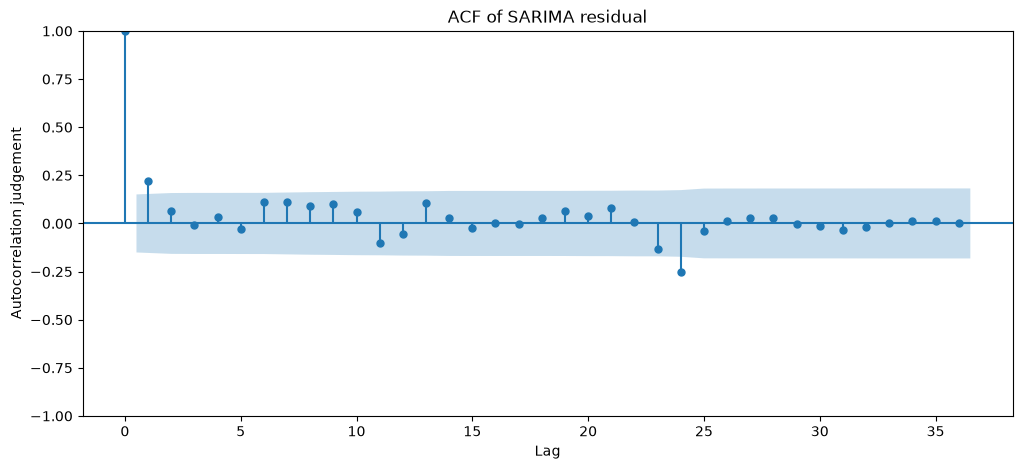

In [50]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
fig, ax=plt.subplots(figsize=(12,5))
plot_acf(residual, lags=36, ax=ax)
ax.set_title("ACF of SARIMA residual")
ax.set_xlabel("Lag")
ax.set_ylabel("Autocorrelation judgement")
plt.show()

In [51]:
#out of confidence range at lag 1 and 24. so have to change the model
from numpy import True_


ljung=acorr_ljungbox(
    residual, lags=[12,24], return_df=True
)
ljung

,lb_stat,lb_pvalue
12,20.398239,0.059918
24,41.364797,0.015185


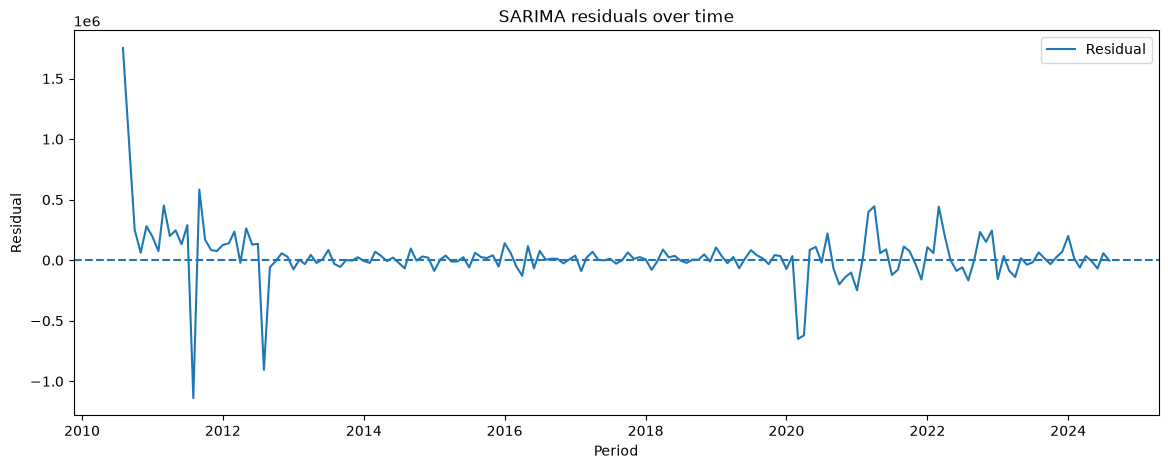

In [52]:
plt.figure(figsize=(14,5))
plt.plot(residual.index, residual, label="Residual")
plt.axhline(0, linestyle="--")
plt.title("SARIMA residuals over time")
plt.xlabel("Period")
plt.ylabel("Residual")

plt.legend()
plt.show()

In [53]:
diag_res= residual.iloc[12:]
print(len(residual))
print(len(diag_res))

169
157


In [54]:
from statsmodels.stats.diagnostic import acorr_ljungbox
ljung_diag=acorr_ljungbox(
    diag_res,
    lags=[12,24],
    return_df=True
)
ljung_diag

,lb_stat,lb_pvalue
12,13.375813,0.342327
24,24.039893,0.459318


In [55]:
#felt an earthquake midway lol
best=fit_mod["SARIMA(1,0,0)(1,1,0,12)"]
forecast=best.forecast(steps=len(test))
fore_df=pd.DataFrame({
    "Actual": test,
    "Forecast": forecast
})
fore_df.head()

,Actual,Forecast
2024-09-01,2214217.0,2.180158e+06
2024-10-01,2360536.0,2.294131e+06
2024-11-01,2314998.0,2.253965e+06
2024-12-01,2345934.0,2.318014e+06
2025-01-01,2218130.0,2.142702e+06


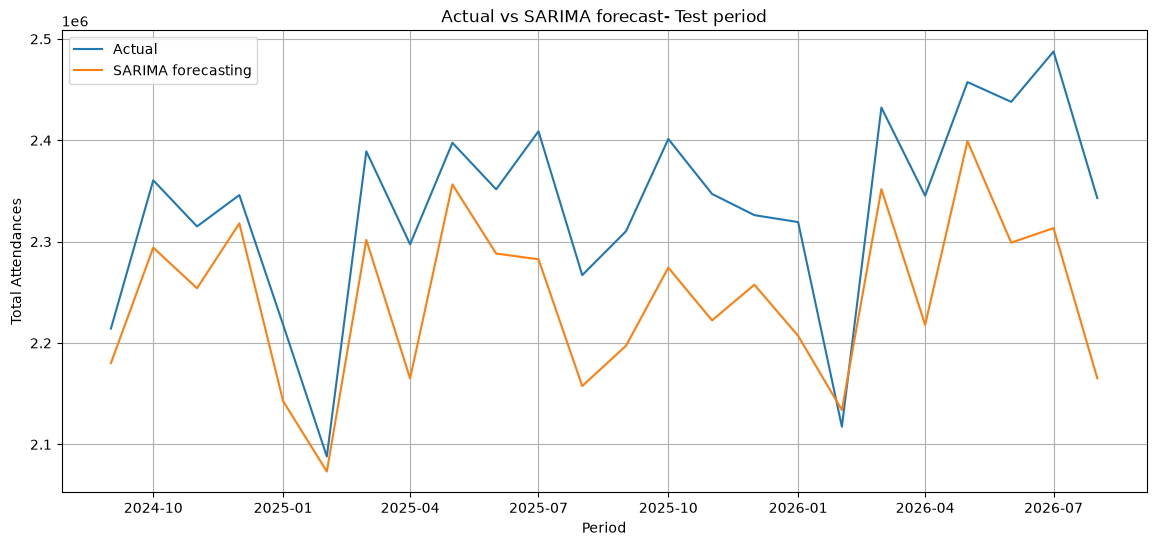

In [56]:
plt.figure(figsize=(14,6))
plt.plot(
    test.index,
    test,
    label="Actual"
)
plt.plot(
    test.index,
    forecast,
    label="SARIMA forecasting"
)
plt.title("Actual vs SARIMA forecast- Test period")
plt.xlabel("Period")
plt.ylabel("Total Attendances")
plt.legend()
plt.grid()
plt.show()


In [57]:
#test-period forecast bias analysis
err= test-forecast
mean_err=err.mean()
bias_per=(mean_err/test.mean())*100
print("Test-period forecast bias")
print("-"* 40 )
print(f"Mean Error: {mean_err:,.2f}")
print(f"MAE: {np.abs(err).mean():,.2f}")
print(f"MAPE: {np.mean(np.abs(err/test))*100:.2f}%")
print(f"Bias: {bias_per:.2f}%")

Test-period forecast bias
----------------------------------------
Mean Error: 88,565.27
MAE: 89,940.19
MAPE: 3.82%
Bias: 3.80%


In [59]:
#model is underforecasting sadly
seasonal_naive_fore= ts.shift(12).loc[test.index]
naive_mae=mean_absolute_error(test, seasonal_naive_fore)
naive_rmse=np.sqrt(mean_absolute_error(test, seasonal_naive_fore))
naive_mape= np.mean(np.abs((test- seasonal_naive_fore)/test))*100
print(f"MAE: {naive_mae:,.2f}")
print(f"RMSE: {naive_rmse:,.2f}")
print(f"MAPE: {naive_mape:.2f}")

MAE: 67,686.96
RMSE: 260.17
MAPE: 2.90
